# -------- Import Libraries --------

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# -------- INPUT ANGLES --------

## In Degrees

In [89]:
theta_deg1 = float(input("Enter rotation angle 1 (degrees): "))
theta_deg2 = float(input("Enter rotation angle 2 (degrees): "))
theta_deg3 = float(input("Enter rotation angle 3 (degrees): "))

In [90]:
print("Joint Value 1:",theta_deg1)
print("Joint Value 2:",theta_deg2)
print("Joint Value 3:",theta_deg3)

Joint Value 1: -85.0
Joint Value 2: -90.0
Joint Value 3: 180.0


## In Radians

In [91]:
theta1 = np.deg2rad(theta_deg1)
theta2 = np.deg2rad(theta_deg2)
theta3 = np.deg2rad(theta_deg3)

In [92]:
print("Joint Value 1:",theta1)
print("Joint Value 2:",theta2)
print("Joint Value 3:",theta3)

Joint Value 1: -1.4835298641951802
Joint Value 2: -1.5707963267948966
Joint Value 3: 3.141592653589793


# -------- LINK LENGTHS --------

In [93]:
l1 = 2
l2 = 2
l3 = 1

In [94]:
print("Link Length 1:",l1)
print("Link Length 2:",l2)
print("Link Length 3:",l3)

Link Length 1: 2
Link Length 2: 2
Link Length 3: 1


# -------- TRANSFORMATION MATRICES --------

In [95]:
T01 = np.array([
    [np.cos(theta1), -np.sin(theta1), 0, 0],
    [np.sin(theta1),  np.cos(theta1), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

T12 = np.array([
    [np.cos(theta2), -np.sin(theta2), 0, l1],
    [np.sin(theta2),  np.cos(theta2), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

T23 = np.array([
    [np.cos(theta3), -np.sin(theta3), 0, l2],
    [np.sin(theta3),  np.cos(theta3), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
T34 = np.array([
    [1, 0, 0, l3],
    [0,  1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])


# -------- GLOBAL TRANSFORMATIONS --------

In [96]:
T02 = T01 @ T12
T03 = T02 @ T23
T04 = T03 @ T34

print("T01:")
print(T01)
print("\n")
print("T02:")
print(T02)
print("\n")
print("T03:")
print(T03)
print("\n")
print("T04:")
print(T04)


T01:
[[ 0.08715574  0.9961947   0.          0.        ]
 [-0.9961947   0.08715574  0.          0.        ]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]


T02:
[[-0.9961947   0.08715574  0.          0.17431149]
 [-0.08715574 -0.9961947   0.         -1.9923894 ]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]


T03:
[[ 0.9961947  -0.08715574  0.         -1.81807791]
 [ 0.08715574  0.9961947   0.         -2.16670088]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]


T04:
[[ 0.9961947  -0.08715574  0.         -0.82188321]
 [ 0.08715574  0.9961947   0.         -2.07954514]
 [ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]]


In [97]:
P1 = T01[:3, 3].reshape(3,1)
P2 = T02[:3, 3].reshape(3,1)
P3 = T03[:3, 3].reshape(3,1)
P4 = T04[:3, 3].reshape(3,1)

# -------- PRINT RESULTS --------

# Position and Orientation of the end-effector w.r.t. fixed base

In [98]:
print("Position of the end-effector w.r.t. fixed base:",P4.flatten())

phi = theta_deg1 + theta_deg2 + theta_deg3
print("Orientation of the end-effector w.r.t. fixed base:",phi)

Position of the end-effector w.r.t. fixed base: [-0.82188321 -2.07954514  0.        ]
Orientation of the end-effector w.r.t. fixed base: 5.0


# -------- PLOT --------

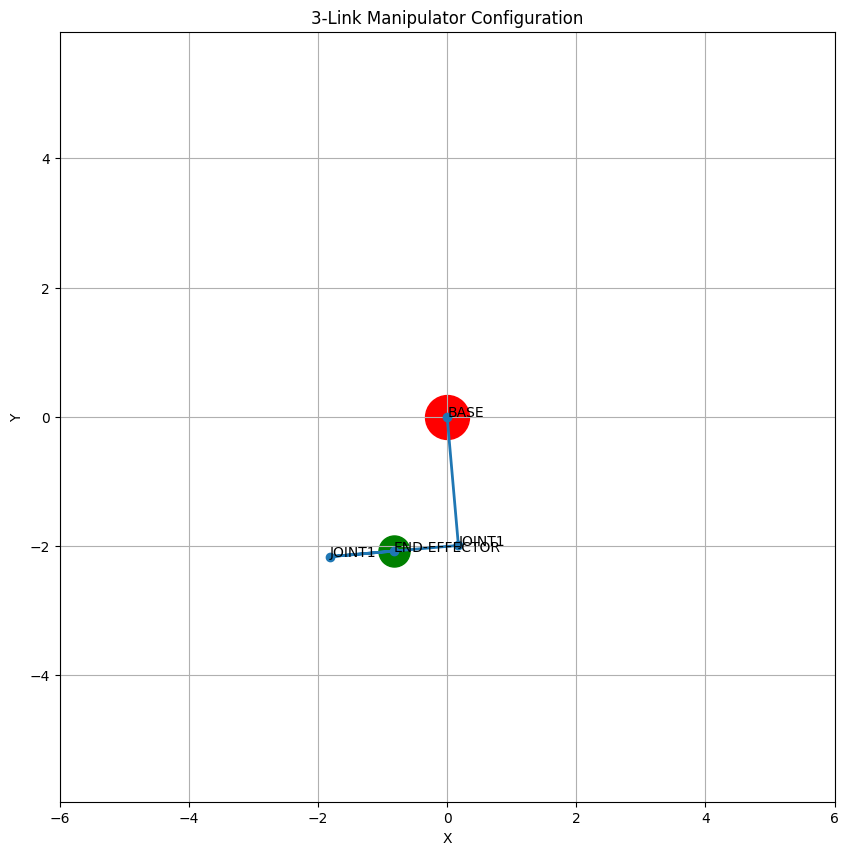

In [99]:
x = [P1[0,0], P2[0,0], P3[0,0], P4[0,0]]
y = [P1[1,0], P2[1,0], P3[1,0], P4[1,0]]

plt.figure(figsize=(10, 10))

plt.plot(x, y, '-o', linewidth=2)


plt.text(P1[0,0], P1[1,0], 'BASE',)
plt.text(P2[0,0], P2[1,0], 'JOINT1')
plt.text(P3[0,0], P3[1,0], 'JOINT1')
plt.text(P4[0,0], P4[1,0], 'END-EFFECTOR')

plt.scatter(P1[0,0], P1[1,0], color='red', s=1000)
plt.scatter(P4[0,0], P4[1,0], color='green', s=500)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("3-Link Manipulator Configuration")

plt.grid(True)
plt.axis('equal')

plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.show()